# Lab 1: Data Preparation & Exploration

In this lab, we will learn how to download, explore, and visualize custom image data for a food classification task.

## Learning Objectives

By the end of this lab, you will be able to:
- Download and organize image datasets from external sources
- Explore dataset structure and understand the ImageFolder format
- Visualize individual and multiple images from the dataset
- Analyze dataset distribution and class balance
- Understand the importance of data exploration before model building

## 0. Setup and Imports

Importing PyTorch and setting up device-agnostic code.

In [3]:
import torch
from torch import nn
print(f'PyTorch version: {torch.__version__}')

PyTorch version: 2.10.0+cpu


In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cpu


### Why Device-Agnostic Code?

Device-agnostic code allows our model to run on **GPU** (if available) or fall back to **CPU**. This makes our code portable and efficient across different hardware configurations.

## 1. Get Data

First things first, we need some data.

And like any good cooking show, some data has already been prepared for us.

We're going to start small.

Machine learning is an **iterative process**: start small, get something working, and increase when necessary.

Let's write some code to download the formatted data from GitHub.

**Note:** The dataset we're about to use has been pre-formatted for what we'd like to use it for. However, you'll often have to format your own datasets for whatever problem you're working on. This is a regular practice in the machine learning world.

In [5]:
import requests
import zipfile
from pathlib import Path

# ✅ requests
# ইন্টারনেট থেকে ফাইল ডাউনলোড করার জন্য ব্যবহার হয়।
# এখানে GitHub থেকে .zip ফাইল নামাতে ব্যবহার হচ্ছে।
# ✅ Path
# ফোল্ডার/ফাইলের পথ (directory path) তৈরি ও ম্যানেজ করার জন্য।
# এটা os এর চেয়ে cleaner ও modern way।

data_path = Path('data/')
image_path = data_path / 'pizza_steak_sushi'

# 👉 data_path
# data/ নামে একটা folder বোঝাচ্ছে।
# 👉 image_path
# data/pizza_steak_sushi ফোল্ডার বানাবে।

#  3️⃣ চেক করছে ফোল্ডার আছে কিনা
if image_path.is_dir():             # যদি আগে থেকেই dataset থাকে:✔ আবার download করবে না✔ শুধু message দেখাবে
    print(f'{image_path} directory exists.')
else:                                           # 4️⃣ যদি ফোল্ডার না থাকে
    print(f'Creating {image_path} directory...')
    image_path.mkdir(parents=True, exist_ok=True)

# ✅ mkdir()
# নতুন folder বানায়
# parents=True → দরকার হলে parent folder ও বানাবে
# exist_ok=True → আগে থাকলেও error দিবে না

    with open(data_path / 'pizza_steak_sushi.zip', 'wb') as f:   #.zip ফাইল write mode (wb = write binary) এ খুলছে
        request = requests.get('https://raw.githubusercontent.com/poridhioss/Introduction-to-Deep-Learning-with-Pytorch-Resources/main/Custom-Datasets/pizza_steak_sushi.zip')
        print('Downloading data...')
        f.write(request.content)

        # 6️⃣ Zip File Extract করা

    with zipfile.ZipFile(data_path / 'pizza_steak_sushi.zip', 'r') as zip_ref:
        print('Unzipping data...')
        zip_ref.extractall(image_path)
    print('Done!')

Creating data/pizza_steak_sushi directory...
Unzipping data...
Done!


Dataset downloaded!

Time to become one with it.

## 2. Explore the Data

Data preparation is paramount. Before building a model, **become one with the data**.

Ask yourself: *What am I trying to do here?*

Before starting a project or building any kind of model, it's important to know what data you're working with.

In our case, we have images of pizza, steak and sushi in **standard image classification format**.

Image classification format contains separate classes of images in separate directories titled with a particular class name.

For example, all images of pizza are contained in the `pizza/` directory.

This format is popular across many different image classification benchmarks, including **ImageNet** (one of the most popular computer vision benchmark datasets).

The goal will be to take this data storage structure and turn it into a dataset usable with PyTorch.

**Note:** The structure of the data you work with will vary depending on the problem you're working on. But the premise still remains: **become one with the data**, then find a way to best turn it into a dataset compatible with PyTorch.

We can inspect what's in our data directory by writing a small helper function to walk through each of the subdirectories and count the files present.

To do so, we'll use Python's built-in `os.walk()`.

In [6]:
import os

def walk_through_dir(dir_path):              # dir_path → যে folder টা explore করতে চাও তার path
    for dirpath, dirnames, filenames in os.walk(dir_path):

# os.walk() পুরো directory tree ঘুরে ঘুরে তিনটা জিনিস দেয়:
# Variable	মানে
# dirpath	বর্তমান folder এর path
# dirnames	ঐ folder এর ভিতরের subfolder list
# filenames	ঐ folder এর ভিতরের file list
        print(f'There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}.')

# len(dirnames) → কয়টা subfolder আছে
# len(filenames) → কয়টা file আছে
# dirpath → কোন folder সেটা

In [7]:
walk_through_dir(image_path)

There are 2 directories and 0 images in data/pizza_steak_sushi.
There are 3 directories and 0 images in data/pizza_steak_sushi/train.
There are 0 directories and 75 images in data/pizza_steak_sushi/train/steak.
There are 0 directories and 72 images in data/pizza_steak_sushi/train/sushi.
There are 0 directories and 78 images in data/pizza_steak_sushi/train/pizza.
There are 3 directories and 0 images in data/pizza_steak_sushi/test.
There are 0 directories and 19 images in data/pizza_steak_sushi/test/steak.
There are 0 directories and 31 images in data/pizza_steak_sushi/test/sushi.
There are 0 directories and 25 images in data/pizza_steak_sushi/test/pizza.


খুব ভালো 👍
এই output দেখে আমরা তোমার dataset structure পুরো বুঝতে পারছি। চলো সহজভাবে বিশ্লেষণ করি 👇

---

# 📂 ১️⃣ Main Folder

```
There are 2 directories and 0 images in data/pizza_steak_sushi.
```

👉 এর মানে:

* `pizza_steak_sushi` ফোল্ডারের ভিতরে **২টা subfolder** আছে
* কোনো image সরাসরি এখানে নেই

এই ২টা folder হলো:

```
train
test
```

✔️ Dataset structure ঠিক আছে

---

# 🧪 ২️⃣ Test Folder

```
There are 3 directories and 0 images in data/pizza_steak_sushi/test.
```

👉 test ফোল্ডারের ভিতরে:

* ৩টা class folder আছে
* সরাসরি কোনো image নেই

এই ৩টা হলো:

```
sushi
steak
pizza
```

---

## 📸 Test Image Count

| Class | Image সংখ্যা |
| ----- | ------------ |
| sushi | 31           |
| steak | 19           |
| pizza | 25           |

মোট test image =
31 + 19 + 25 = **75 images**

---

# 🏋️ ৩️⃣ Train Folder

```
There are 3 directories and 0 images in data/pizza_steak_sushi/train.
```

👉 train ফোল্ডারের ভিতরেও ৩টা class folder আছে।

---

## 📸 Train Image Count

| Class | Image সংখ্যা |
| ----- | ------------ |
| sushi | 72           |
| steak | 75           |
| pizza | 78           |

মোট train image =
72 + 75 + 78 = **225 images**

---

# 📊 ৪️⃣ পুরো Dataset Summary

| Type  | Total Images |
| ----- | ------------ |
| Train | 225          |
| Test  | 75           |
| Total | 300          |

---

# 🎯 এখন আমরা কী বুঝলাম?

✅ Dataset structure ঠিক আছে (ImageFolder friendly)
✅ 3টা class আছে → pizza, steak, sushi
✅ Train/Test split already করা
✅ মোট 300 image আছে
✅ মোটামুটি balanced dataset (খুব বেশি imbalance না)

---

# 🧠 Deep Learning এর জন্য এর মানে কী?

* Output layer এ **3 neurons** লাগবে (3 class)
* Loss function হবে: `CrossEntropyLoss`
* Problem type: **Multiclass Classification**
* Dataset size ছোট → overfitting হওয়ার সম্ভাবনা আছে

---


### What Did We Learn?

From our exploration, we discovered:
- **3 classes**: pizza, steak, and sushi
- **Training samples**: 225 images total (75 steak + 72 sushi + 78 pizza)
- **Test samples**: 75 images total (19 steak + 31 sushi + 25 pizza)
- **Split ratio**: Approximately 75% train / 25% test

This is enough data to get started with a simple classification model!

In [8]:
train_dir = image_path / 'train'
test_dir = image_path / 'test'
print(f'Training directory: {train_dir}')
print(f'Testing directory: {test_dir}')

Training directory: data/pizza_steak_sushi/train
Testing directory: data/pizza_steak_sushi/test


Excellent!

That should be enough to get started.

## 3. Visualize an Image

Okay, we've seen how our directory structure is formatted.

Now in the spirit of the data explorer, it's time to **visualize, visualize, visualize!**

Let's write some code to:

1. Get all of the image paths using `pathlib.Path.glob()` to find all of the files ending in `.jpg`
2. Pick a random image path using Python's `random.choice()`
3. Get the image class name using `pathlib.Path.parent.stem`
4. Open the random image path using `PIL.Image.open()` (PIL stands for Python Image Library)
5. Show the image and print some metadata

In [9]:
import random
from PIL import Image

random.seed(42)
image_path_list = list(image_path.glob('*/*/*.jpg'))   # 👉 অর্থাৎ সব image এর path একসাথে list হচ্ছে।
random_image_path = random.choice(image_path_list)
image_class = random_image_path.parent.stem     # Image এর class বের করা
img = Image.open(random_image_path)

print(f'Image path: {random_image_path}')
print(f'Image class: {image_class}')
print(f'Image size: {img.width}x{img.height}')

Image path: data/pizza_steak_sushi/train/steak/239025.jpg
Image class: steak
Image size: 384x512


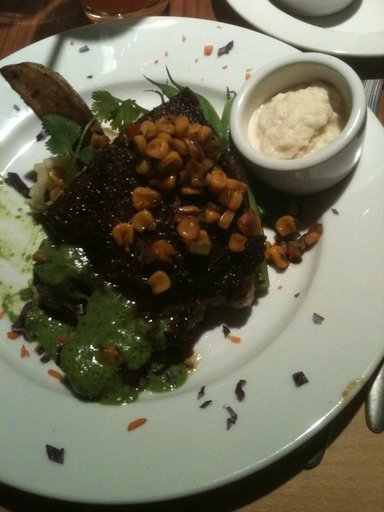

In [10]:
img

We can do the same with matplotlib.pyplot.imshow(), except we have to convert the image to a NumPy array first.

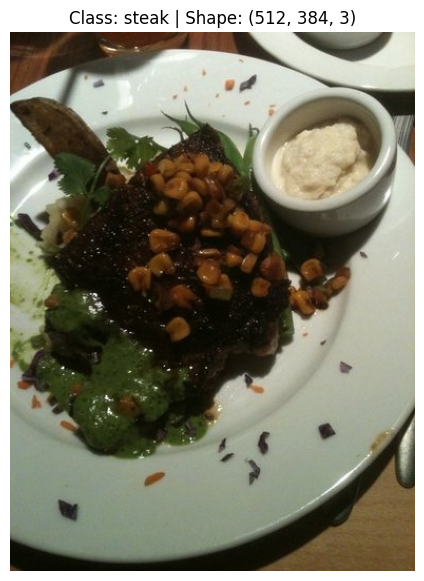

In [11]:
import numpy as np
import matplotlib.pyplot as plt

img_as_array = np.asarray(img)
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f'Class: {image_class} | Shape: {img_as_array.shape}')
plt.axis(False)
plt.show()

## 4. Visualize Multiple Images

### Why Look at Multiple Images?

While examining a single image gives us basic information, viewing multiple images simultaneously provides deeper insights:

- **Intra-class variability**: How different can images of the same food look? (different angles, lighting, backgrounds, plating styles) একই class হলেও image গুলো অনেক আলাদা হতে পারে।
- **Inter-class patterns**: What visual features help distinguish one class from another? class গুলোর পার্থক্য
- **Data quality assessment**: Are all images clear and properly labeled?
অনেক সময় dataset এ সমস্যা থাকে:
blur image
ভুল label
duplicate image
irrelevant image
Multiple image দেখলে এগুলো ধরা যায়।
- **Edge cases**: Can we spot potentially challenging examples that might confuse our model?
কিছু image confusing হতে পারে।এগুলো আগে দেখলে বুঝা যায় model কোথায় ভুল করতে পারে।



### Building a Visualization Helper

Let's create a reusable function to display multiple random images side-by-side. This function will:
1. Randomly sample `n` images using `random.sample()`
2. Create a subplot grid with `matplotlib`
3. Display each image with its class label
4. Use `seed` parameter for reproducibility

In [12]:
# Parameters:
# image_path → dataset এর main folder path
# n=3 → কয়টা image দেখাবে (default 3)
# seed=42 → reproducibility এর জন্য

def plot_random_images(image_path, n=3, seed=42):
    random.seed(seed)
    image_paths = list(Path(image_path).glob('*/*/*.jpg'))  # এটা dataset এর সব .jpg file এর path list বানাচ্ছে।  যেমনঃ train/pizza/*.jpg
    random_paths = random.sample(image_paths, k=n)

    fig, axes = plt.subplots(1, n, figsize=(15, 5))     # 👉 1 row, n column এর grid বানাচ্ছে।
    for ax, path in zip(axes, random_paths):
        img = Image.open(path)
        ax.imshow(img)
        ax.set_title(f'Class: {path.parent.stem}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

### Display Random Sample

Now let's use our function to visualize 3 random images from across all classes:

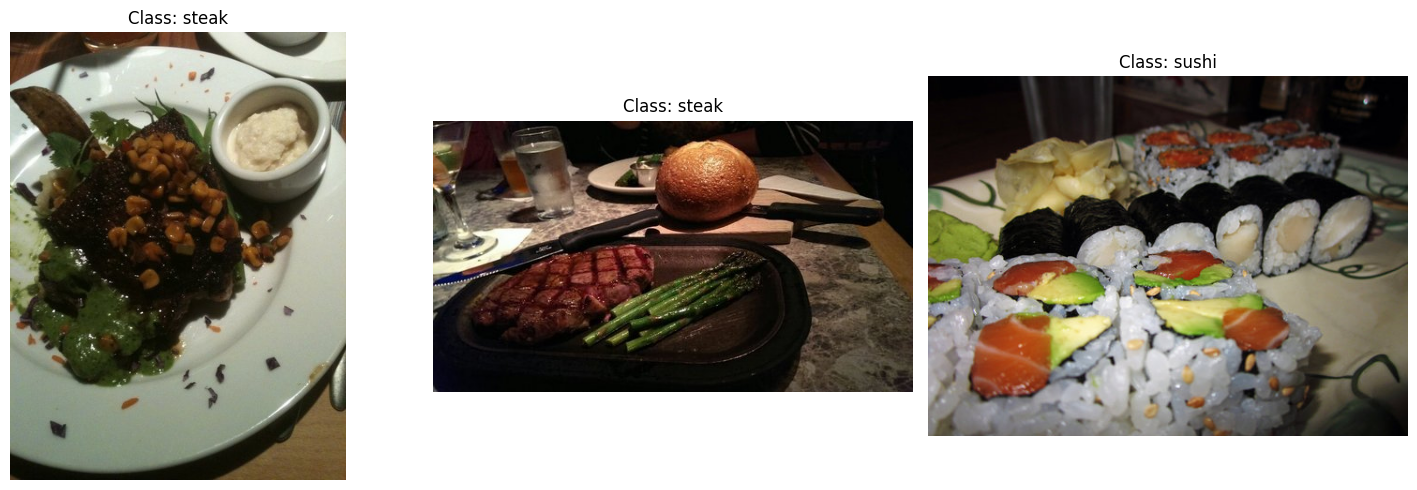

In [13]:
plot_random_images(image_path, n=3, seed=42)

### Observations from Multiple Images

From viewing multiple images, we can observe:

**Visual Diversity:**
- Each food category has distinct visual characteristics
- Images vary in terms of angle, zoom level, and presentation
- Different lighting conditions and backgrounds

**Classification Clues:**
- **Pizza**: Circular shape, cheese texture, toppings visible
- **Steak**: Brown/charred appearance, meat texture, often with grill marks
- **Sushi**: Rice visible, distinct rolls or nigiri shapes, often on plates

**Important Notes:**
- Some images might be more challenging than others (e.g., close-ups vs. full shots)
- Real-world variability means our model needs to learn robust features
- This diversity is actually **good** - it helps our model generalize better!

💡 **Tip**: If you notice any patterns or potential issues in the data, this is the time to address them before training.

## 5. Summary Statistics

In [14]:
print('Training set:')
for d in train_dir.iterdir():          # iterdir() train_dir এর ভিতরের সব file ও folder এক এক করে দেয়।
    if d.is_dir():                     # নিশ্চিত করছে যে এটা folder (class folder), file না।
        count = len(list(d.glob('*.jpg')))        # d.glob('*.jpg') → ঐ class folder এর সব jpg file নিচ্ছে
        print(f'  {d.name}: {count} images')      # d.name → folder নাম (pizza / steak / sushi)

Training set:
  steak: 75 images
  sushi: 72 images
  pizza: 78 images


In [15]:
print('Test set:')
for d in test_dir.iterdir():
    if d.is_dir():
        count = len(list(d.glob('*.jpg')))
        print(f'  {d.name}: {count} images')

Test set:
  steak: 19 images
  sushi: 31 images
  pizza: 25 images


## Key Takeaways

- Data is organized in ImageFolder format
- Variable image sizes, RGB format
- Next: Lab 2 - Transform and load with DataLoaders